# 04 - Optimización de hiperparámetros

Este notebook optimiza hiperparámetros de los modelos seleccionados a partir del diagnóstico realizado en `03_model_evaluation`.

La optimización se realiza exclusivamente sobre el conjunto de entrenamiento mediante validación cruzada. El conjunto de prueba se reserva para medir el impacto final de los modelos optimizados.

Se utilizan dos estrategias:

- `GridSearchCV`: búsqueda exhaustiva sobre grillas pequeñas y controladas.
- `RandomizedSearchCV`: búsqueda aleatoria para espacios de búsqueda más amplios o modelos de mayor costo computacional.

Este notebook no selecciona todavía el modelo final del proyecto. Su función es medir si la optimización técnica mejora los modelos seleccionados desde el diagnóstico anterior. La decisión final se realiza en `05_final_analysis`.

El análisis de umbral realizado en el notebook 03 no se considera hiperparámetro técnico del modelo. Ese umbral corresponde a una decisión de negocio y no se optimiza en esta etapa.

## 1. Importación de librerías y módulos del proyecto

Se importan librerías generales, funciones de preprocesamiento, funciones de evaluación y funciones de búsqueda de hiperparámetros desde `src`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import json
import joblib
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import crear_preprocesador
from src.model_training import obtener_modelos_clasificacion, obtener_modelos_regresion
from src.model_evaluation import (
    evaluar_modelos_clasificacion,
    evaluar_modelos_regresion,
    guardar_metricas,
)
from src.hyperparameter_tuning import (
    optimizar_gridsearch_clasificacion,
    optimizar_randomsearch_clasificacion,
    optimizar_randomsearch_regresion,
    extraer_resultados_busqueda,
    resumir_mejor_modelo,
    combinar_resumenes_busqueda,
    combinar_resultados_busqueda,
    guardar_dataframe,
)

## 2. Configuración de rutas y parámetros generales

El notebook reutiliza los artefactos generados previamente por `02_supervised_modeling` y `03_model_evaluation`. No se crean nuevos splits ni se cambia el dataset de entrada.

`OPTIMIZAR_SVM` se mantiene como opción configurable debido al mayor costo computacional esperado de este modelo. En esta ejecución se priorizan `Logistic Regression`, `Decision Tree Classifier` y `Decision Tree Regressor`.

In [2]:
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
PLOTS_DIR = PROJECT_ROOT / "results" / "plots"
SPLITS_DIR = PROJECT_ROOT / "results" / "splits"
MODELS_DIR = PROJECT_ROOT / "models" / "trained_models"

for directory in [METRICS_DIR, PLOTS_DIR, SPLITS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

METADATA_PATH = MODELS_DIR / "modeling_metadata.json"
MANIFEST_PATH = MODELS_DIR / "trained_models_manifest.csv"

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró models/trained_models/modeling_metadata.json. "
        "Ejecuta primero notebooks/02_supervised_modeling.ipynb."
    )

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

DATA_PATH = PROJECT_ROOT / metadata["data_path"]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset indicado en metadata: {DATA_PATH}")

RANDOM_STATE = metadata["random_state"]
CV_SPLITS = 5

# SVM se mantiene como optimización opcional por costo computacional.
# Cambiar a True si el tiempo de ejecución lo permite.
OPTIMIZAR_SVM = False

print("Proyecto raíz:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Metadata:", METADATA_PATH)
print("Random state:", RANDOM_STATE)
print("CV splits:", CV_SPLITS)
print("Optimizar SVM:", OPTIMIZAR_SVM)

Proyecto raíz: /datasets/_deepnote_work
Dataset: /datasets/_deepnote_work/data/processed/data_transformada.csv
Metadata: /datasets/_deepnote_work/models/trained_models/modeling_metadata.json
Random state: 42
CV splits: 5
Optimizar SVM: False


## 3. Carga de métricas base

Se cargan las métricas generadas en el notebook 03. Estas métricas funcionan como referencia para comparar el impacto de la optimización.

La comparación principal debe realizarse contra las métricas formales del notebook 03. Si estas no existen, el notebook puede usar métricas preliminares del notebook 02 como respaldo, aunque la comparación recomendada es contra los resultados del 03.

In [3]:
classification_base_metrics_path = METRICS_DIR / "classification_test_metrics.csv"
regression_base_metrics_path = METRICS_DIR / "regression_test_metrics.csv"

if not classification_base_metrics_path.exists():
    # Respaldo si solo existe la salida del notebook 02.
    classification_base_metrics_path = METRICS_DIR / "classification_base_metrics.csv"

if not regression_base_metrics_path.exists():
    regression_base_metrics_path = METRICS_DIR / "regression_base_metrics.csv"

if not classification_base_metrics_path.exists() or not regression_base_metrics_path.exists():
    raise FileNotFoundError(
        "No se encontraron métricas base de clasificación/regresión. "
        "Ejecuta primero los notebooks 02 y 03."
    )

df_clf_base = pd.read_csv(classification_base_metrics_path)
df_reg_base = pd.read_csv(regression_base_metrics_path)

print("Fuente métricas clasificación:", classification_base_metrics_path)
print("Fuente métricas regresión:", regression_base_metrics_path)

print("Métricas base de clasificación:")
display(df_clf_base)

print("Métricas base de regresión:")
display(df_reg_base)

Fuente métricas clasificación: /datasets/_deepnote_work/results/metrics/classification_test_metrics.csv
Fuente métricas regresión: /datasets/_deepnote_work/results/metrics/regression_test_metrics.csv
Métricas base de clasificación:


,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.65500,0.604230,0.378072,0.465116,0.688220
1,Decision Tree Classifier,0.55875,0.447212,0.475110,0.460739,0.544435
2,SVM,0.64450,0.602230,0.306238,0.406015,0.656956


Métricas base de regresión:


,modelo,mae,rmse,r2
0,Linear Regression,0.816414,1.006381,-0.001963
1,Decision Tree Regressor,1.152062,1.426339,-1.012671


## 4. Carga del dataset y reconstrucción de conjuntos

Se reconstruyen los conjuntos de entrenamiento y prueba usando exactamente los índices guardados por el notebook 02. Esto evita crear una nueva partición y permite que la comparación entre modelos base y optimizados sea justa.

La reconstrucción de los conjuntos no repite el modelado base: solo recupera la misma base experimental para poder entrenar configuraciones optimizadas sobre `train` y evaluarlas sobre el mismo `test` usado en el notebook 03.

In [4]:
df = pd.read_csv(DATA_PATH)

TARGET_CLASIFICACION = metadata["target_clasificacion"]
TARGET_REGRESION = metadata["target_regresion"]

classification_train_indices_path = PROJECT_ROOT / metadata["classification_train_indices"]
classification_test_indices_path = PROJECT_ROOT / metadata["classification_test_indices"]
regression_train_indices_path = PROJECT_ROOT / metadata["regression_train_indices"]
regression_test_indices_path = PROJECT_ROOT / metadata["regression_test_indices"]
label_mapping_path = PROJECT_ROOT / metadata["classification_label_mapping"]

for path in [
    classification_train_indices_path,
    classification_test_indices_path,
    regression_train_indices_path,
    regression_test_indices_path,
    label_mapping_path,
]:
    if not path.exists():
        raise FileNotFoundError(f"No se encontró archivo requerido: {path}")

print("Dimensiones del dataset:", df.shape)
print("Target clasificación:", TARGET_CLASIFICACION)
print("Target regresión:", TARGET_REGRESION)

Dimensiones del dataset: (20000, 38)
Target clasificación: abandono
Target regresión: gasto_mensual


### 4.1 Reconstrucción del problema de clasificación

Se reconstruye la matriz de variables predictoras y el target de clasificación usando la misma lógica del modelado base.

In [5]:
df_clf = df.dropna(subset=[TARGET_CLASIFICACION]).copy()

columnas_excluir_clf = [TARGET_CLASIFICACION]
if "id_cliente" in df_clf.columns:
    columnas_excluir_clf.append("id_cliente")

X_clf = df_clf.drop(columns=columnas_excluir_clf)
y_clf_original = df_clf[TARGET_CLASIFICACION]

label_encoder_clf = LabelEncoder()
y_clf = pd.Series(
    label_encoder_clf.fit_transform(y_clf_original),
    index=df_clf.index,
    name=TARGET_CLASIFICACION,
)

train_indices_clf = pd.read_csv(classification_train_indices_path)["index"].tolist()
test_indices_clf = pd.read_csv(classification_test_indices_path)["index"].tolist()

X_train_clf = X_clf.loc[train_indices_clf]
y_train_clf = y_clf.loc[train_indices_clf]
X_test_clf = X_clf.loc[test_indices_clf]
y_test_clf = y_clf.loc[test_indices_clf]

df_label_mapping = pd.read_csv(label_mapping_path)

print("Columnas excluidas en clasificación:", columnas_excluir_clf)
print("Train clasificación:", X_train_clf.shape)
print("Test clasificación:", X_test_clf.shape)
display(df_label_mapping)

Columnas excluidas en clasificación: ['abandono']
Train clasificación: (16000, 37)
Test clasificación: (4000, 37)


,clase_original,clase_codificada
0,0,0
1,1,1


### 4.2 Reconstrucción del problema de regresión

Se reconstruye el problema de regresión usando `gasto_mensual` como variable objetivo. Se excluyen variables que no deben actuar como predictoras, incluyendo `abandono` y variables derivadas directamente del target si existen.

In [6]:
df_reg = df.dropna(subset=[TARGET_REGRESION]).copy()

columnas_excluir_reg = [TARGET_REGRESION]
for col in ["id_cliente", TARGET_CLASIFICACION, "ratio_gasto_ingreso"]:
    if col in df_reg.columns:
        columnas_excluir_reg.append(col)

X_reg = df_reg.drop(columns=columnas_excluir_reg)
y_reg = pd.to_numeric(df_reg[TARGET_REGRESION], errors="coerce")

filas_validas_reg = y_reg.notna()
X_reg = X_reg.loc[filas_validas_reg]
y_reg = y_reg.loc[filas_validas_reg]

train_indices_reg = pd.read_csv(regression_train_indices_path)["index"].tolist()
test_indices_reg = pd.read_csv(regression_test_indices_path)["index"].tolist()

X_train_reg = X_reg.loc[train_indices_reg]
y_train_reg = y_reg.loc[train_indices_reg]
X_test_reg = X_reg.loc[test_indices_reg]
y_test_reg = y_reg.loc[test_indices_reg]

print("Columnas excluidas en regresión:", columnas_excluir_reg)
print("Train regresión:", X_train_reg.shape)
print("Test regresión:", X_test_reg.shape)

Columnas excluidas en regresión: ['gasto_mensual', 'abandono', 'ratio_gasto_ingreso']
Train regresión: (16000, 35)
Test regresión: (4000, 35)


## 5. Reconstrucción de pipelines candidatos

Se construyen nuevas plantillas de pipelines para optimización. Estos pipelines no modifican directamente los `.pkl` entrenados en el notebook 02.

`GridSearchCV` y `RandomizedSearchCV` necesitan recibir pipelines no ajustados para entrenar múltiples configuraciones sobre el conjunto de entrenamiento. Por eso esta reconstrucción es necesaria en el notebook 04 y no representa una repetición del notebook 02.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import sys
import json
import joblib
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

# Se asume que las variables y funciones importadas en celdas anteriores existen en el kernel
# (crear_preprocesador, obtener_modelos_clasificacion, obtener_modelos_regresion,
#  X_train_clf, X_train_reg, RANDOM_STATE, grupos_clf, grupos_reg, etc.)

# Reconstrucción de pipelines candidatos y fix de string multilinea en print
preprocesador_clf_escalado, grupos_clf = crear_preprocesador(X_train_clf, escalar=True)
preprocesador_clf_arbol, _ = crear_preprocesador(X_train_clf, escalar=False)

preprocesador_reg_arbol, grupos_reg = crear_preprocesador(X_train_reg, escalar=False)

modelos_base_clf = obtener_modelos_clasificacion(random_state=RANDOM_STATE)
modelos_base_reg = obtener_modelos_regresion(random_state=RANDOM_STATE)

pipeline_logistic = Pipeline(steps=[
    ("preprocesamiento", preprocesador_clf_escalado),
    ("modelo", modelos_base_clf["Logistic Regression"]),
])

pipeline_tree_clf = Pipeline(steps=[
    ("preprocesamiento", preprocesador_clf_arbol),
    ("modelo", modelos_base_clf["Decision Tree Classifier"]),
])

pipeline_svm = Pipeline(steps=[
    ("preprocesamiento", preprocesador_clf_escalado),
    ("modelo", modelos_base_clf["SVM"]),
])

pipeline_tree_reg = Pipeline(steps=[
    ("preprocesamiento", preprocesador_reg_arbol),
    ("modelo", modelos_base_reg["Decision Tree Regressor"]),
])

print("Pipelines candidatos listos.")
print("Columnas clasificación:")
for grupo, columnas in grupos_clf.items():
    print(f"- {grupo}: {columnas}")

# Asegurar que no haya problemas de comillas o secuencias de escape en el print siguiente
print("\nColumnas regresión:")
for grupo, columnas in grupos_reg.items():
    print(f"- {grupo}: {columnas}")

Pipelines candidatos listos.
Columnas clasificación:
- outliers: ['ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio', 'ratio_deuda_ingreso', 'ratio_gasto_ingreso']
- numericas: ['edad', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos', 'anio', 'genero_Femenino', 'genero_Masculino', 'genero_Otro', 'region_Centro', 'region_Norte', 'region_Sur', 'estado_civil_Casado', 'estado_civil_Divorciado', 'estado_civil_Soltero', 'uso_app_Alto', 'uso_app_Bajo', 'uso_app_Medio', 'tipo_plan_Basico', 'tipo_plan_Estandar', 'tipo_plan_Premium', 'canal_registro_App', 'canal_registro_Tienda', 'canal_registro_Web']
- categoricas: []
- binarias: ['tiene_tarjeta_credito']
- ciclicas: ['hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos']

Columnas regresión:
- outliers: ['ingreso_mensual', 'deuda_total', 'score_crediticio', 'ratio_deuda_ingreso']
- numericas: ['edad', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num

## 6. Definición de espacios de búsqueda

Los hiperparámetros se definieron a partir del diagnóstico del notebook 03.

| Modelo | Método | Scoring | Motivo |
|---|---|---|---|
| Logistic Regression | GridSearchCV | f1 | Mejor equilibrio base; se busca mejorar balance entre precision y recall |
| Decision Tree Classifier | GridSearchCV | f1 | Mayor recall base, pero exceso de falsos positivos |
| SVM | RandomizedSearchCV | f1 | Candidato opcional por costo computacional |
| Decision Tree Regressor | RandomizedSearchCV | neg_root_mean_squared_error | Reducir error de predicción |

La métrica `f1` se usa en clasificación porque combina `precision` y `recall`, lo que resulta más adecuado que optimizar únicamente `accuracy` en un problema de abandono.

In [8]:
param_grid_logistic = {
    "modelo__C": [0.01, 0.1, 1, 10],
    "modelo__class_weight": [None, "balanced"],
}

param_grid_tree_clf = {
    "modelo__max_depth": [3, 5, 7, 10, None],
    "modelo__min_samples_split": [2, 10, 25],
    "modelo__min_samples_leaf": [1, 5, 10],
    "modelo__criterion": ["gini", "entropy"],
    "modelo__class_weight": [None, "balanced"],
}

param_distributions_svm = {
    "modelo__C": [0.1, 1, 10],
    "modelo__kernel": ["linear", "rbf"],
    "modelo__gamma": ["scale", "auto"],
    "modelo__class_weight": [None, "balanced"],
}

param_distributions_tree_reg = {
    "modelo__max_depth": [3, 5, 7, 10],
    "modelo__min_samples_split": [10, 25],
    "modelo__min_samples_leaf": [5, 10],
    "modelo__criterion": ["squared_error"],
}

SCORING_CLF = "f1"
SCORING_REG = "neg_root_mean_squared_error"

print("Espacios de búsqueda definidos.")

Espacios de búsqueda definidos.


## 7. Optimización de Logistic Regression

Se utiliza `GridSearchCV` porque el espacio de búsqueda es pequeño y controlado. La métrica objetivo es `f1`, ya que permite equilibrar `precision` y `recall` en el problema de abandono.

In [9]:
busquedas = {}
resultados_busqueda = []
resumenes_busqueda = []
modelos_clasificacion_optimizados = {}
modelos_regresion_optimizados = {}

busqueda_logistic = optimizar_gridsearch_clasificacion(
    pipeline=pipeline_logistic,
    param_grid=param_grid_logistic,
    X_train=X_train_clf,
    y_train=y_train_clf,
    scoring=SCORING_CLF,
    cv_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
)

busquedas["Logistic Regression"] = busqueda_logistic
modelos_clasificacion_optimizados["Logistic Regression"] = busqueda_logistic.best_estimator_

resultados_busqueda.append(
    extraer_resultados_busqueda(
        busqueda_logistic,
        nombre_modelo="Logistic Regression",
        tipo_modelo="classification",
        metodo="GridSearchCV",
    )
)

resumenes_busqueda.append(
    resumir_mejor_modelo(
        busqueda_logistic,
        nombre_modelo="Logistic Regression",
        tipo_modelo="classification",
        metodo="GridSearchCV",
        scoring=SCORING_CLF,
    )
)

print("Mejor score CV:", busqueda_logistic.best_score_)
print("Mejores parámetros:")
print(busqueda_logistic.best_params_)

Mejor score CV: 0.5654712399436104
Mejores parámetros:
{'modelo__C': 1, 'modelo__class_weight': 'balanced'}


### Lectura de la optimización de Logistic Regression

La optimización de `Logistic Regression` seleccionó `C=1` y `class_weight="balanced"`.

El efecto principal del ajuste fue aumentar considerablemente el `recall` y el `f1_score`. Esto indica que el modelo optimizado detecta una proporción mayor de clientes que realmente abandonan.

Sin embargo, esta mejora ocurre a costa de una disminución en `precision` y `accuracy`. El modelo se vuelve menos conservador y clasifica más clientes como posibles abandonos, lo que mejora la detección, pero también aumenta las falsas alertas.

El `roc_auc` se mantiene prácticamente igual, por lo que la optimización no mejora de forma relevante la capacidad global de separación entre clases. La mejora principal proviene del ajuste del peso de clases.

Como varias configuraciones de `C` pueden obtener scores muy cercanos dentro de la grilla definida, el cambio más relevante no es el valor exacto de `C`, sino la selección de `class_weight="balanced"`.

## 8. Optimización de Decision Tree Classifier

Se utiliza `GridSearchCV` para explorar configuraciones de profundidad, criterios de división y tamaño mínimo de nodos. El objetivo es controlar la complejidad del árbol, ya que en la evaluación base este modelo mostró mayor `recall`, pero también demasiados falsos positivos.

In [10]:
busqueda_tree_clf = optimizar_gridsearch_clasificacion(
    pipeline=pipeline_tree_clf,
    param_grid=param_grid_tree_clf,
    X_train=X_train_clf,
    y_train=y_train_clf,
    scoring=SCORING_CLF,
    cv_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
)

busquedas["Decision Tree Classifier"] = busqueda_tree_clf
modelos_clasificacion_optimizados["Decision Tree Classifier"] = busqueda_tree_clf.best_estimator_

resultados_busqueda.append(
    extraer_resultados_busqueda(
        busqueda_tree_clf,
        nombre_modelo="Decision Tree Classifier",
        tipo_modelo="classification",
        metodo="GridSearchCV",
    )
)

resumenes_busqueda.append(
    resumir_mejor_modelo(
        busqueda_tree_clf,
        nombre_modelo="Decision Tree Classifier",
        tipo_modelo="classification",
        metodo="GridSearchCV",
        scoring=SCORING_CLF,
    )
)

print("Mejor score CV:", busqueda_tree_clf.best_score_)
print("Mejores parámetros:")
print(busqueda_tree_clf.best_params_)

Mejor score CV: 0.5659430015946476
Mejores parámetros:
{'modelo__class_weight': 'balanced', 'modelo__criterion': 'entropy', 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}


### Lectura de la optimización de Decision Tree Classifier

La optimización de `Decision Tree Classifier` produjo una mejora clara frente al árbol base. El modelo optimizado mejora `accuracy`, `precision`, `recall`, `f1_score` y `roc_auc`.

La configuración seleccionada utiliza `max_depth=5`, `criterion="entropy"` y `class_weight="balanced"`. Esto confirma que el árbol base necesitaba control de complejidad y ajuste del peso de clases.

Este resultado valida el diagnóstico del notebook 03: el árbol tenía potencial por su mayor `recall`, pero requería regulación mediante hiperparámetros para controlar falsos positivos y mejorar su capacidad general de separación.

## 9. Optimización opcional de SVM

`SVM` se mantiene como candidato opcional por su mayor costo computacional esperado. Si `OPTIMIZAR_SVM = True`, se utiliza `RandomizedSearchCV` para probar una cantidad limitada de combinaciones.

En esta ejecución, SVM no se optimiza por defecto. Esta decisión no afecta la evaluación principal del notebook 04, ya que los modelos priorizados para optimización son `Logistic Regression` y `Decision Tree Classifier` en clasificación.

In [11]:
if OPTIMIZAR_SVM:
    busqueda_svm = optimizar_randomsearch_clasificacion(
        pipeline=pipeline_svm,
        param_distributions=param_distributions_svm,
        X_train=X_train_clf,
        y_train=y_train_clf,
        scoring=SCORING_CLF,
        n_iter=8,
        cv_splits=CV_SPLITS,
        random_state=RANDOM_STATE,
    )

    busquedas["SVM"] = busqueda_svm
    modelos_clasificacion_optimizados["SVM"] = busqueda_svm.best_estimator_

    resultados_busqueda.append(
        extraer_resultados_busqueda(
            busqueda_svm,
            nombre_modelo="SVM",
            tipo_modelo="classification",
            metodo="RandomizedSearchCV",
        )
    )

    resumenes_busqueda.append(
        resumir_mejor_modelo(
            busqueda_svm,
            nombre_modelo="SVM",
            tipo_modelo="classification",
            metodo="RandomizedSearchCV",
            scoring=SCORING_CLF,
        )
    )

    print("Mejor score CV:", busqueda_svm.best_score_)
    print("Mejores parámetros:")
    print(busqueda_svm.best_params_)
else:
    print("Optimización de SVM omitida. Se mantiene como candidato opcional por costo computacional.")

Optimización de SVM omitida. Se mantiene como candidato opcional por costo computacional.


## 10. Optimización de Decision Tree Regressor

Se utiliza `RandomizedSearchCV` para explorar configuraciones del árbol de regresión. La métrica de búsqueda es `neg_root_mean_squared_error`, porque se busca reducir el error de predicción de `gasto_mensual`.

In [12]:
busqueda_tree_reg = optimizar_randomsearch_regresion(
    pipeline=pipeline_tree_reg,
    param_distributions=param_distributions_tree_reg,
    X_train=X_train_reg,
    y_train=y_train_reg,
    scoring=SCORING_REG,
    n_iter=6,
    cv_splits=3,
    random_state=RANDOM_STATE,
)

busquedas["Decision Tree Regressor"] = busqueda_tree_reg
modelos_regresion_optimizados["Decision Tree Regressor"] = busqueda_tree_reg.best_estimator_

resultados_busqueda.append(
    extraer_resultados_busqueda(
        busqueda_tree_reg,
        nombre_modelo="Decision Tree Regressor",
        tipo_modelo="regression",
        metodo="RandomizedSearchCV",
    )
)

resumenes_busqueda.append(
    resumir_mejor_modelo(
        busqueda_tree_reg,
        nombre_modelo="Decision Tree Regressor",
        tipo_modelo="regression",
        metodo="RandomizedSearchCV",
        scoring=SCORING_REG,
    )
)

print("Mejor score CV:", busqueda_tree_reg.best_score_)
print("Mejores parámetros:")
print(busqueda_tree_reg.best_params_)

Mejor score CV: -1.0011921848221934
Mejores parámetros:
{'modelo__min_samples_split': 10, 'modelo__min_samples_leaf': 5, 'modelo__max_depth': 3, 'modelo__criterion': 'squared_error'}


### Lectura de la optimización de Decision Tree Regressor

La optimización de `Decision Tree Regressor` mejora de forma importante su rendimiento frente al árbol base. El `RMSE` disminuye y el `R²` pasa de un valor fuertemente negativo a un valor cercano a cero.

Esto muestra que controlar la complejidad del árbol evita gran parte del mal desempeño inicial.

Sin embargo, el modelo optimizado no supera a `Linear Regression`, que continúa siendo levemente mejor en `MAE`, `RMSE` y `R²`. Por lo tanto, la optimización corrige el árbol de regresión, pero no convierte la regresión en un componente predictivo fuerte.

## 11. Resumen de búsquedas de hiperparámetros

Se consolidan los mejores parámetros y los resultados completos de las búsquedas realizadas.

El resumen de búsqueda permite identificar la mejor configuración encontrada dentro de los espacios definidos. Estos resultados deben interpretarse como la mejor configuración dentro de la grilla o distribución probada, no como una búsqueda absoluta de todos los hiperparámetros posibles.

In [13]:
df_search_summary = combinar_resumenes_busqueda(resumenes_busqueda)
df_search_results = combinar_resultados_busqueda(resultados_busqueda)

# Convertir diccionarios a texto para guardar en CSV de forma legible.
df_search_summary["best_params"] = df_search_summary["best_params"].astype(str)
if not df_search_results.empty and "params" in df_search_results.columns:
    df_search_results["params"] = df_search_results["params"].astype(str)

search_summary_path = METRICS_DIR / "hyperparameter_search_summary.csv"
search_results_path = METRICS_DIR / "hyperparameter_search_results.csv"

guardar_dataframe(df_search_summary, search_summary_path)
guardar_dataframe(df_search_results, search_results_path)

display(df_search_summary)
print("Resumen de búsqueda guardado en:", search_summary_path)
print("Resultados completos de búsqueda guardados en:", search_results_path)

,modelo,tipo_modelo,metodo_busqueda,scoring,best_score_cv,best_params
0,Logistic Regression,classification,GridSearchCV,f1,0.565471,"{'modelo__C': 1, 'modelo__class_weight': 'bala..."
1,Decision Tree Classifier,classification,GridSearchCV,f1,0.565943,"{'modelo__class_weight': 'balanced', 'modelo__..."
2,Decision Tree Regressor,regression,RandomizedSearchCV,neg_root_mean_squared_error,-1.001192,"{'modelo__min_samples_split': 10, 'modelo__min..."


Resumen de búsqueda guardado en: /datasets/_deepnote_work/results/metrics/hyperparameter_search_summary.csv
Resultados completos de búsqueda guardados en: /datasets/_deepnote_work/results/metrics/hyperparameter_search_results.csv


### Lectura del resumen de búsqueda

En clasificación, tanto `Logistic Regression` como `Decision Tree Classifier` seleccionan `class_weight="balanced"`, lo que confirma la importancia de considerar el equilibrio entre clases para mejorar la detección de abandono.

El `best_score_cv` resume el rendimiento promedio obtenido durante la validación cruzada sobre el conjunto de entrenamiento. Este valor no debe confundirse con el rendimiento final en test, que se evalúa en el siguiente bloque.

## 12. Evaluación de modelos optimizados sobre test

Los mejores estimadores encontrados por la búsqueda se evalúan sobre el mismo conjunto de prueba usado en el notebook 03. El test no se utiliza para elegir hiperparámetros; solo se usa para medir el impacto final de los modelos optimizados sobre datos no usados durante la búsqueda.

In [14]:
df_clf_optimized, matrices_confusion_optimized = evaluar_modelos_clasificacion(
    modelos_clasificacion_optimizados,
    X_test_clf,
    y_test_clf,
)

df_reg_optimized = evaluar_modelos_regresion(
    modelos_regresion_optimizados,
    X_test_reg,
    y_test_reg,
)

classification_optimized_metrics_path = METRICS_DIR / "classification_optimized_metrics.csv"
regression_optimized_metrics_path = METRICS_DIR / "regression_optimized_metrics.csv"

guardar_metricas(df_clf_optimized, classification_optimized_metrics_path)
guardar_metricas(df_reg_optimized, regression_optimized_metrics_path)

print("Métricas de clasificación optimizada:")
display(df_clf_optimized)

print("Métricas de regresión optimizada:")
display(df_reg_optimized)

Métricas de clasificación optimizada:


,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.63825,0.537076,0.638941,0.583597,0.688326
1,Decision Tree Classifier,0.63000,0.527116,0.655325,0.584270,0.673731


Métricas de regresión optimizada:


,modelo,mae,rmse,r2
0,Decision Tree Regressor,0.81781,1.007213,-0.003621


### Lectura de modelos optimizados en test

En clasificación, los modelos optimizados quedan muy cercanos en `f1_score`. `Decision Tree Classifier` obtiene mayor `recall`, mientras que `Logistic Regression` mantiene mejor `precision`, mayor `accuracy` y mejor `roc_auc`.

En regresión, `Decision Tree Regressor` mejora considerablemente frente a su versión base, pero esta mejora debe compararse también con `Linear Regression`, que se mantiene como línea base de regresión.

## 13. Comparación base vs optimizado

Se comparan los modelos optimizados contra sus versiones base. Esta comparación permite determinar si la búsqueda de hiperparámetros produjo mejoras reales o solo desplazó el rendimiento entre métricas.

La comparación base vs optimizado es el centro del notebook 04: no basta con obtener `best_params_`; es necesario verificar si esos parámetros mejoran el rendimiento sobre test.

In [15]:
def preparar_comparacion_base_optimizado(df_base, df_opt, metricas):
    base = df_base[df_base["modelo"].isin(df_opt["modelo"])].copy()
    opt = df_opt.copy()

    comparacion = base.merge(opt, on="modelo", suffixes=("_base", "_optimizado"))

    for metrica in metricas:
        col_base = f"{metrica}_base"
        col_opt = f"{metrica}_optimizado"
        if col_base in comparacion.columns and col_opt in comparacion.columns:
            comparacion[f"delta_{metrica}"] = comparacion[col_opt] - comparacion[col_base]

    return comparacion

metricas_clf = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
metricas_reg = ["mae", "rmse", "r2"]

df_clf_base_vs_opt = preparar_comparacion_base_optimizado(df_clf_base, df_clf_optimized, metricas_clf)
df_reg_base_vs_opt = preparar_comparacion_base_optimizado(df_reg_base, df_reg_optimized, metricas_reg)

classification_base_vs_optimized_path = METRICS_DIR / "classification_base_vs_optimized.csv"
regression_base_vs_optimized_path = METRICS_DIR / "regression_base_vs_optimized.csv"

guardar_metricas(df_clf_base_vs_opt, classification_base_vs_optimized_path)
guardar_metricas(df_reg_base_vs_opt, regression_base_vs_optimized_path)

print("Comparación clasificación base vs optimizado:")
display(df_clf_base_vs_opt)

print("Comparación regresión base vs optimizado:")
display(df_reg_base_vs_opt)

Comparación clasificación base vs optimizado:


,modelo,accuracy_base,precision_base,recall_base,f1_score_base,roc_auc_base,accuracy_optimizado,precision_optimizado,recall_optimizado,f1_score_optimizado,roc_auc_optimizado,delta_accuracy,delta_precision,delta_recall,delta_f1_score,delta_roc_auc
0,Logistic Regression,0.65500,0.604230,0.378072,0.465116,0.688220,0.63825,0.537076,0.638941,0.583597,0.688326,-0.01675,-0.067153,0.260870,0.118481,0.000106
1,Decision Tree Classifier,0.55875,0.447212,0.475110,0.460739,0.544435,0.63000,0.527116,0.655325,0.584270,0.673731,0.07125,0.079904,0.180214,0.123530,0.129296


Comparación regresión base vs optimizado:


,modelo,mae_base,rmse_base,r2_base,mae_optimizado,rmse_optimizado,r2_optimizado,delta_mae,delta_rmse,delta_r2
0,Decision Tree Regressor,1.152062,1.426339,-1.012671,0.81781,1.007213,-0.003621,-0.334252,-0.419126,1.009049


### Lectura de comparación base vs optimizado

La comparación base vs optimizado muestra que ambos modelos principales de clasificación mejoran en `f1_score` después de la optimización.

`Logistic Regression` mejora principalmente en `recall`, pero baja en `precision` y `accuracy`. Esto indica que el modelo se vuelve menos conservador y detecta más clientes que abandonan.

`Decision Tree Classifier` mejora en todas las métricas, incluyendo `roc_auc`, lo que indica que la optimización no solo cambió el equilibrio entre errores, sino que también mejoró su capacidad general de separación.

En regresión, `Decision Tree Regressor` mejora fuertemente respecto a su versión base, aunque su rendimiento optimizado sigue siendo comparable o levemente inferior a `Linear Regression`.

## 14. Visualización de comparación en clasificación

Se comparan métricas base y optimizadas para los modelos de clasificación ajustados.

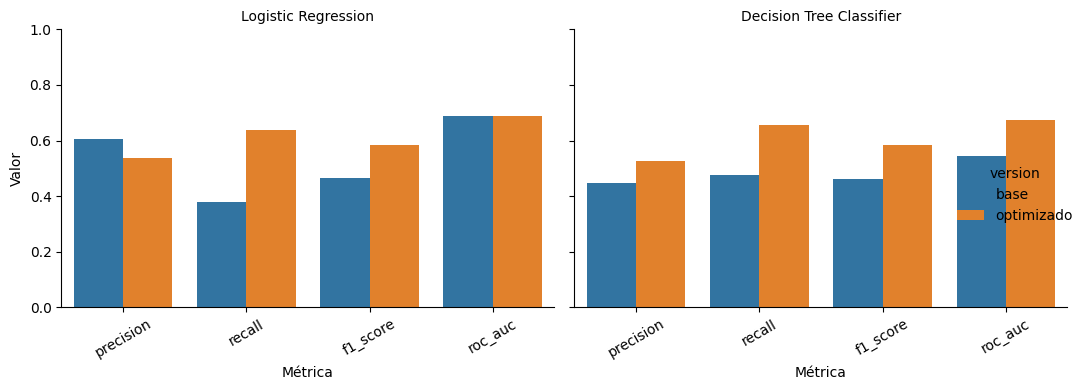

Gráfico guardado en: /datasets/_deepnote_work/results/plots/classification_base_vs_optimized_by_model.png


In [16]:
if not df_clf_base_vs_opt.empty:
    metricas_plot_clf = ["precision", "recall", "f1_score", "roc_auc"]
    registros_plot = []

    for _, row in df_clf_base_vs_opt.iterrows():
        for metrica in metricas_plot_clf:
            registros_plot.append({
                "modelo": row["modelo"],
                "metrica": metrica,
                "version": "base",
                "valor": row[f"{metrica}_base"],
            })
            registros_plot.append({
                "modelo": row["modelo"],
                "metrica": metrica,
                "version": "optimizado",
                "valor": row[f"{metrica}_optimizado"],
            })

    df_plot_clf = pd.DataFrame(registros_plot)

    g = sns.catplot(
        data=df_plot_clf,
        x="metrica",
        y="valor",
        hue="version",
        col="modelo",
        kind="bar",
        height=4,
        aspect=1.2,
        sharey=True,
    )

    g.set_titles("{col_name}")
    g.set_axis_labels("Métrica", "Valor")

    for ax in g.axes.flat:
        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()

    classification_base_vs_optimized_plot_path = PLOTS_DIR / "classification_base_vs_optimized_by_model.png"
    g.figure.savefig(classification_base_vs_optimized_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Gráfico guardado en:", classification_base_vs_optimized_plot_path)
else:
    print("No hay modelos de clasificación optimizados para graficar.")

### Lectura de la comparación visual de clasificación

La visualización separa cada modelo para evitar mezclar rendimientos. Esto permite observar que la optimización impacta de manera distinta a cada clasificador.

En `Logistic Regression`, la mejora se concentra principalmente en `recall` y `f1_score`, mientras que `precision` disminuye. En `Decision Tree Classifier`, la mejora es más amplia y se refleja en todas las métricas comparadas.

## 15. Matrices de confusión de modelos optimizados

Las matrices de confusión permiten observar si la optimización redujo falsos negativos, falsos positivos o cambió el equilibrio entre ambos tipos de error.

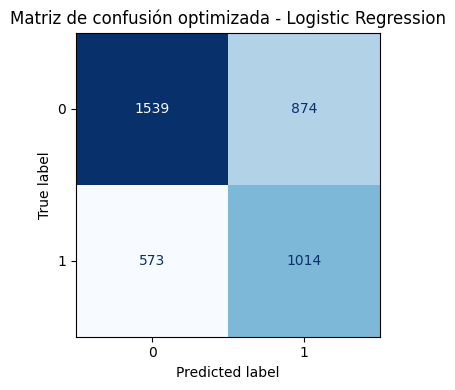

Guardado: /datasets/_deepnote_work/results/plots/optimized_confusion_matrix_logistic_regression.png


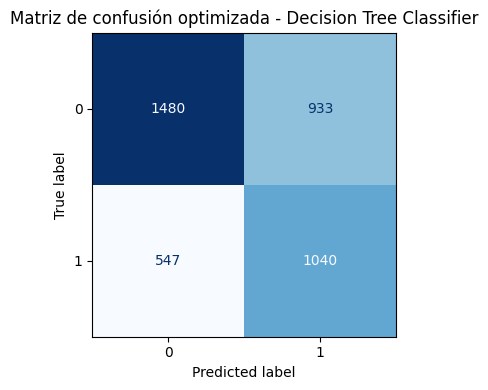

Guardado: /datasets/_deepnote_work/results/plots/optimized_confusion_matrix_decision_tree_classifier.png


In [17]:
for nombre, modelo in modelos_clasificacion_optimizados.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        modelo,
        X_test_clf,
        y_test_clf,
        ax=ax,
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(f"Matriz de confusión optimizada - {nombre}")
    plt.tight_layout()

    nombre_archivo = re.sub(r"[^a-z0-9]+", "_", nombre.lower()).strip("_")
    ruta_plot = PLOTS_DIR / f"optimized_confusion_matrix_{nombre_archivo}.png"
    fig.savefig(ruta_plot, dpi=150, bbox_inches="tight")
    plt.show()

    print("Guardado:", ruta_plot)

In [18]:
# Comparación tabular de matrices de confusión: modelos base vs optimizados.
# Fix: importar confusion_matrix si no está en el namespace
try:
    confusion_matrix
except NameError:
    from sklearn.metrics import confusion_matrix

# También asegurarnos de que pandas y joblib estén importados en este bloque por robustez
try:
    pd
except NameError:
    import pandas as pd

try:
    joblib
except NameError:
    import joblib

# Ejecutar la lógica original

df_base_manifest = pd.read_csv(MANIFEST_PATH)
registros_confusion = []

for nombre, modelo_optimizado in modelos_clasificacion_optimizados.items():
    fila_base = df_base_manifest[
        (df_base_manifest["tipo_modelo"] == "classification")
        & (df_base_manifest["modelo"] == nombre)
    ]

    if not fila_base.empty:
        ruta_modelo_base = PROJECT_ROOT / fila_base.iloc[0]["ruta_modelo"]
        modelo_base = joblib.load(ruta_modelo_base)
        y_pred_base = modelo_base.predict(X_test_clf)
        tn, fp, fn, tp = confusion_matrix(y_test_clf, y_pred_base).ravel()

        registros_confusion.append({
            "modelo": nombre,
            "version": "base",
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })

    y_pred_opt = modelo_optimizado.predict(X_test_clf)
    tn, fp, fn, tp = confusion_matrix(y_test_clf, y_pred_opt).ravel()

    registros_confusion.append({
        "modelo": nombre,
        "version": "optimizado",
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })


df_confusion_base_vs_optimized = pd.DataFrame(registros_confusion)
classification_confusion_comparison_path = METRICS_DIR / "classification_confusion_base_vs_optimized.csv"
guardar_metricas(df_confusion_base_vs_optimized, classification_confusion_comparison_path)

# Mostrar y registrar ruta
try:
    display
except NameError:
    pass
else:
    display(df_confusion_base_vs_optimized)

print("Comparación de matrices de confusión guardada en:", classification_confusion_comparison_path)

,modelo,version,tn,fp,fn,tp
0,Logistic Regression,base,2020,393,987,600
1,Logistic Regression,optimizado,1539,874,573,1014
2,Decision Tree Classifier,base,1481,932,833,754
3,Decision Tree Classifier,optimizado,1480,933,547,1040


Comparación de matrices de confusión guardada en: /datasets/_deepnote_work/results/metrics/classification_confusion_base_vs_optimized.csv


### Lectura de matrices de confusión optimizadas

Las matrices de confusión permiten revisar si la optimización cambió el tipo de error cometido por los modelos.

En `Logistic Regression`, el uso de `class_weight="balanced"` aumenta la detección de abandonos reales, reduciendo falsos negativos, aunque puede aumentar falsos positivos.

En `Decision Tree Classifier`, la optimización mejora el equilibrio general del árbol: mantiene una alta detección de abandonos y mejora el comportamiento respecto a la versión base, que generaba demasiadas falsas alertas.

## 16. Visualización y referencia de regresión

Se separan errores (`MAE`, `RMSE`) y `R²`, porque se interpretan en direcciones distintas: los errores son mejores cuando bajan, mientras que `R²` es mejor cuando sube.

Además de comparar `Decision Tree Regressor` base vs optimizado, se agrega una comparación contra `Linear Regression`, que funciona como línea base de regresión.

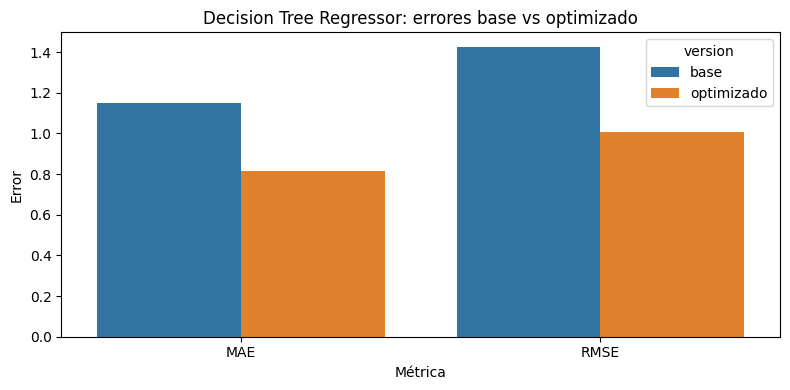

Gráfico de errores guardado en: /datasets/_deepnote_work/results/plots/regression_base_vs_optimized_errors.png


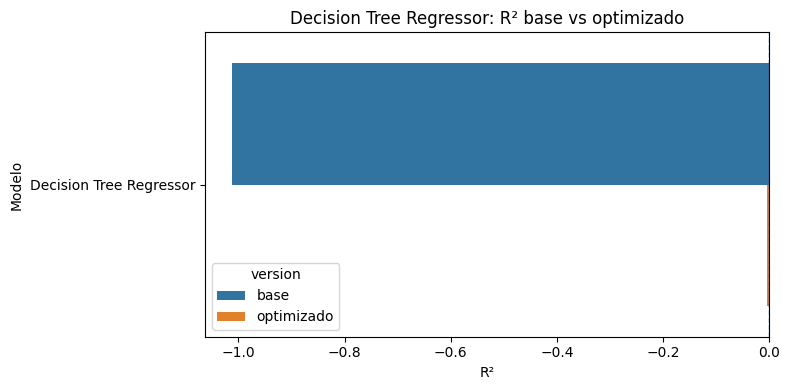

Gráfico de R² guardado en: /datasets/_deepnote_work/results/plots/regression_base_vs_optimized_r2.png


,modelo,version,mae,rmse,r2
0,Linear Regression,baseline,0.816414,1.006381,-0.001963
1,Decision Tree Regressor,optimizado,0.817810,1.007213,-0.003621


Comparación contra baseline lineal guardada en: /datasets/_deepnote_work/results/metrics/regression_linear_vs_tree_optimized.csv


In [19]:
if not df_reg_base_vs_opt.empty:
    registros_error = []
    for _, row in df_reg_base_vs_opt.iterrows():
        for metrica in ["mae", "rmse"]:
            registros_error.append({
                "modelo": row["modelo"],
                "metrica": metrica.upper(),
                "version": "base",
                "valor": row[f"{metrica}_base"],
            })
            registros_error.append({
                "modelo": row["modelo"],
                "metrica": metrica.upper(),
                "version": "optimizado",
                "valor": row[f"{metrica}_optimizado"],
            })

    df_plot_reg_error = pd.DataFrame(registros_error)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_plot_reg_error, x="metrica", y="valor", hue="version")
    plt.title("Decision Tree Regressor: errores base vs optimizado")
    plt.xlabel("Métrica")
    plt.ylabel("Error")
    plt.tight_layout()

    regression_errors_plot_path = PLOTS_DIR / "regression_base_vs_optimized_errors.png"
    plt.savefig(regression_errors_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Gráfico de errores guardado en:", regression_errors_plot_path)

    registros_r2 = []
    for _, row in df_reg_base_vs_opt.iterrows():
        registros_r2.append({"modelo": row["modelo"], "version": "base", "r2": row["r2_base"]})
        registros_r2.append({"modelo": row["modelo"], "version": "optimizado", "r2": row["r2_optimizado"]})

    df_plot_reg_r2 = pd.DataFrame(registros_r2)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_plot_reg_r2, x="r2", y="modelo", hue="version", orient="h")
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title("Decision Tree Regressor: R² base vs optimizado")
    plt.xlabel("R²")
    plt.ylabel("Modelo")
    plt.tight_layout()

    regression_r2_plot_path = PLOTS_DIR / "regression_base_vs_optimized_r2.png"
    plt.savefig(regression_r2_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Gráfico de R² guardado en:", regression_r2_plot_path)
else:
    print("No hay modelos de regresión optimizados para graficar.")

# Comparación explícita con Linear Regression como baseline.
registros_referencia_reg = []

if "modelo" in df_reg_base.columns:
    fila_linear = df_reg_base[df_reg_base["modelo"] == "Linear Regression"]
    if not fila_linear.empty:
        fila = fila_linear.iloc[0]
        registros_referencia_reg.append({
            "modelo": "Linear Regression",
            "version": "baseline",
            "mae": fila["mae"],
            "rmse": fila["rmse"],
            "r2": fila["r2"],
        })

fila_tree_opt = df_reg_optimized[df_reg_optimized["modelo"] == "Decision Tree Regressor"]
if not fila_tree_opt.empty:
    fila = fila_tree_opt.iloc[0]
    registros_referencia_reg.append({
        "modelo": "Decision Tree Regressor",
        "version": "optimizado",
        "mae": fila["mae"],
        "rmse": fila["rmse"],
        "r2": fila["r2"],
    })

df_regression_reference = pd.DataFrame(registros_referencia_reg)
regression_reference_path = METRICS_DIR / "regression_linear_vs_tree_optimized.csv"
guardar_metricas(df_regression_reference, regression_reference_path)

display(df_regression_reference)
print("Comparación contra baseline lineal guardada en:", regression_reference_path)

### Lectura de regresión después de optimización

`Decision Tree Regressor` mejora de forma considerable frente a su versión base. Sin embargo, al compararlo contra `Linear Regression`, el árbol optimizado no logra superar a la línea base lineal.

Esto indica que la optimización corrigió el mal comportamiento inicial del árbol, pero no resolvió la baja capacidad explicativa general de la tarea de regresión. Por ello, la regresión se mantiene como un componente complementario del análisis.

## 17. Guardado de modelos optimizados

Se serializan los mejores estimadores encontrados para que puedan utilizarse en el análisis final del notebook 05.

Estos modelos no reemplazan automáticamente a los modelos finales del proyecto. Quedan disponibles para ser comparados e integrados en `05_final_analysis`.

In [20]:
def normalizar_nombre_archivo(nombre: str) -> str:
    nombre = nombre.lower().strip()
    nombre = re.sub(r"[^a-z0-9]+", "_", nombre)
    return nombre.strip("_")

registros_modelos_optimizados = []

for nombre, modelo in modelos_clasificacion_optimizados.items():
    ruta_modelo = MODELS_DIR / f"optimized_classification_{normalizar_nombre_archivo(nombre)}_pipeline.pkl"
    joblib.dump(modelo, ruta_modelo)
    registros_modelos_optimizados.append({
        "tipo_modelo": "classification",
        "modelo": nombre,
        "ruta_modelo": str(ruta_modelo.relative_to(PROJECT_ROOT)),
    })

for nombre, modelo in modelos_regresion_optimizados.items():
    ruta_modelo = MODELS_DIR / f"optimized_regression_{normalizar_nombre_archivo(nombre)}_pipeline.pkl"
    joblib.dump(modelo, ruta_modelo)
    registros_modelos_optimizados.append({
        "tipo_modelo": "regression",
        "modelo": nombre,
        "ruta_modelo": str(ruta_modelo.relative_to(PROJECT_ROOT)),
    })

df_optimized_manifest = pd.DataFrame(registros_modelos_optimizados)
optimized_manifest_path = MODELS_DIR / "optimized_models_manifest.csv"
df_optimized_manifest.to_csv(optimized_manifest_path, index=False)

display(df_optimized_manifest)
print("Manifest de modelos optimizados guardado en:", optimized_manifest_path)

,tipo_modelo,modelo,ruta_modelo
0,classification,Logistic Regression,models/trained_models/optimized_classification...
1,classification,Decision Tree Classifier,models/trained_models/optimized_classification...
2,regression,Decision Tree Regressor,models/trained_models/optimized_regression_dec...


Manifest de modelos optimizados guardado en: /datasets/_deepnote_work/models/trained_models/optimized_models_manifest.csv


## 18. Lectura final del impacto de la optimización

La optimización tuvo un impacto positivo en los modelos de clasificación.

`Logistic Regression` aumentó fuertemente su `recall` y su `f1_score`, aunque con una reducción en `precision` y `accuracy`. Esto indica que el modelo optimizado detecta más clientes que abandonan, pero genera más falsas alertas.

`Decision Tree Classifier` presentó la mejora más amplia, aumentando todas sus métricas respecto a la versión base. Esto confirma que el control de complejidad y el peso de clases eran necesarios para mejorar el árbol.

Después de la optimización, ambos modelos quedan muy cercanos en `f1_score`. `Decision Tree Classifier` logra mayor `recall`, mientras que `Logistic Regression` mantiene mayor `precision`, `accuracy` y `roc_auc`.

En regresión, `Decision Tree Regressor` mejora de forma considerable frente a su versión base, pero no supera a `Linear Regression`. La tarea de regresión sigue mostrando baja capacidad explicativa.

Por lo tanto, el notebook 05 deberá comparar principalmente `Logistic Regression` optimizado y `Decision Tree Classifier` optimizado para clasificación, manteniendo la regresión como análisis complementario.

## 19. Comprobaciones finales

Se verifica que los principales archivos generados por el notebook existan correctamente.

In [21]:
archivos_requeridos = [
    search_summary_path,
    search_results_path,
    classification_optimized_metrics_path,
    regression_optimized_metrics_path,
    classification_base_vs_optimized_path,
    regression_base_vs_optimized_path,
    optimized_manifest_path,
]

# Archivos adicionales generados por las mejoras de lectura y visualización.
archivos_adicionales = [
    globals().get("classification_base_vs_optimized_plot_path"),
    globals().get("classification_confusion_comparison_path"),
    globals().get("regression_errors_plot_path"),
    globals().get("regression_r2_plot_path"),
    globals().get("regression_reference_path"),
]

archivos_requeridos.extend([ruta for ruta in archivos_adicionales if ruta is not None])

checks = []
for ruta in archivos_requeridos:
    checks.append({
        "archivo": str(ruta.relative_to(PROJECT_ROOT)),
        "existe": ruta.exists(),
    })

for ruta_modelo in df_optimized_manifest["ruta_modelo"]:
    ruta = PROJECT_ROOT / ruta_modelo
    checks.append({
        "archivo": ruta_modelo,
        "existe": ruta.exists(),
    })

df_checks = pd.DataFrame(checks)
display(df_checks)

pendientes = (~df_checks["existe"]).sum()
print("Archivos pendientes:", pendientes)

,archivo,existe
0,results/metrics/hyperparameter_search_summary.csv,True
1,results/metrics/hyperparameter_search_results.csv,True
2,results/metrics/classification_optimized_metri...,True
3,results/metrics/regression_optimized_metrics.csv,True
4,results/metrics/classification_base_vs_optimiz...,True
5,results/metrics/regression_base_vs_optimized.csv,True
6,models/trained_models/optimized_models_manifes...,True
7,results/plots/classification_base_vs_optimized...,True
8,results/metrics/classification_confusion_base_...,True
9,results/plots/regression_base_vs_optimized_err...,True


Archivos pendientes: 0


## 20. Cierre

La optimización de hiperparámetros permitió mejorar los modelos principales de clasificación.

`Logistic Regression` optimizado mejora fuertemente en `recall` y `f1_score`, principalmente por el uso de `class_weight="balanced"`. Sin embargo, esta mejora implica una reducción en `precision` y `accuracy`.

`Decision Tree Classifier` optimizado mejora en todas las métricas evaluadas y queda muy competitivo frente a `Logistic Regression`. Su mayor ventaja es el `recall`, mientras que `Logistic Regression` conserva mejor `roc_auc`, mayor `precision` y una estructura más simple.

En regresión, `Decision Tree Regressor` optimizado mejora notablemente frente a su versión base, pero no supera a `Linear Regression`. Por ello, la regresión continúa siendo un componente complementario del análisis.

Los resultados de este notebook dejan como principales alternativas para el análisis final a `Logistic Regression` optimizado y `Decision Tree Classifier` optimizado. La decisión final deberá considerar no solo las métricas, sino también el tipo de error más relevante para el problema de abandono.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a797108b-ff37-4667-9d30-00c3227a6ce3' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>